# Side View Only Volume Estimation
# Frozen Feature Extractor + Regression Head

This notebook trains and evaluates different combinations of frozen feature extractors and regression heads on the ONLY the diagonal view data.


In [1]:
import datetime
import json
import warnings
from IPython.display import display
from sklearn.model_selection import ParameterGrid
from src.helpers import *
from src.frozen_pipeline import *
from src.training_and_evaluation import *
from src.constants import *

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)

/home/lenka-hake/Documents/CV/ComputerVisionProject/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Load Data


In [2]:
samples, image_paths = load_paths(DIAGONAL_CSV_PATH, DIAGONAL_FOLDER)
print("Samples shape:", samples.shape)
display(samples[["exp_id", "volume", "pic_path"]].head(8))

Samples shape: (41, 4)


,exp_id,volume,pic_path
0,1,0.00,photos/diagonal_view_images/G0034910.JPG
1,1,0.00,photos/diagonal_view_images/G0034918.JPG
2,1,0.00,photos/diagonal_view_images/G0034926.JPG
3,1,0.00,photos/diagonal_view_images/G0034934.JPG
4,1,1.06,photos/diagonal_view_images/G0035230.JPG
5,1,1.06,photos/diagonal_view_images/G0035231.JPG
6,1,1.06,photos/diagonal_view_images/G0035232.JPG
7,1,1.06,photos/diagonal_view_images/G0035233.JPG


## Setup

In [3]:
DIAGONAL_OUTER_SPLITS = 2
DIAGONAL_INNER_SPLITS = 2

## Show Regression Model Configurations


In [4]:
print("Grid sizes per regressor:")
for name, (_, grid) in BEST_REGRESSION_MODEL_CONFIGS.items():
    n = len(list(ParameterGrid(grid))) if grid else 1
    print(f"  {name:15s}: {n:4d}")

Grid sizes per regressor:
  linear         :    1
  ridge          :    7
  elasticnet     :   16


## Nested CV Evaluation (split by experiment IDs) - Backbone X Regression Model

In [5]:
all_results = []
nested_artifacts = {}

for backbone_name in BEST_BACKBONE_NAMES:
    embedding_memory_cache = {}
    fusion_name = "diagonal only"
    print(f"\n{'#'*90}")
    print(f"Evaluating backbone={backbone_name}, fusion={fusion_name}")
    print(f"{'#'*90}")

    X, y, groups = build_single_view_feature_matrix(
        samples=samples,
        backbone_name=backbone_name,
        image_path_col="pic_path",
        cache_dir=EMBEDDING_CACHE_DIR,
        device=DEVICE,
        mask_paths=DIAGONAL_ROI_MASKS,
        embedding_memory_cache=embedding_memory_cache
    )

    nested_results, oof_predictions = run_nested_cv(
        X=X,
        y=y,
        groups=groups,
        model_configs=NO_PARMS_REGRESSION_MODEL_CONFIGS,
        outer_splits=DIAGONAL_OUTER_SPLITS,
        inner_splits=DIAGONAL_INNER_SPLITS,
    )

    summary_df = summarise_nested_results(nested_results, backbone_name, fusion_name)
    all_results.append(summary_df)
    nested_artifacts[(backbone_name, fusion_name)] = {
        "X": X,
        "y": y,
        "groups": groups,
        "nested_results": nested_results,
        "oof_predictions": oof_predictions,
    }

results_df = pd.concat(all_results, ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)


##########################################################################################
Evaluating backbone=densenet121, fusion=diagonal only
##########################################################################################


densenet121 | pic_path: 100%|██████████| 41/41 [00:00<00:00, 4533.55it/s]


GroupKFold | linear
Fold 1: MAE=0.590, RMSE=0.707, R2=0.7673818042753074, best={}
Fold 2: MAE=0.403, RMSE=0.485, R2=0.832229071972627, best={}

GroupKFold | ridge
Fold 1: MAE=0.594, RMSE=0.703, R2=0.7699442947273261, best={}
Fold 2: MAE=0.418, RMSE=0.499, R2=0.8223983383754353, best={}

GroupKFold | elasticnet


Fold 1: MAE=0.611, RMSE=0.703, R2=0.7699348992228668, best={}
Fold 2: MAE=0.580, RMSE=0.720, R2=0.631119295619234, best={}


## Add Dummy Mean Predictions for Comparison

In [6]:
dummy_pred = np.full(len(samples), samples["volume"].mean(), dtype=float)
dummy_mae = mean_absolute_error(samples["volume"], dummy_pred)
dummy_mse = mean_squared_error(samples["volume"], dummy_pred)
dummy_rmse = np.sqrt(dummy_mse)
dummy_r2 = r2_score(samples["volume"], dummy_pred)

dummy_row = pd.DataFrame([{
    "backbone": "dummy_mean",
    "fusion": "dummy_mean",
    "regressor": "dummy_mean",
    "cv_mae_mean": dummy_mae,
    "cv_mae_std": 0.0,
    "cv_mse_mean": dummy_mse,
    "cv_mse_std": 0.0,
    "cv_rmse_mean": dummy_rmse,
    "cv_rmse_std": 0.0,
    "cv_r2_mean": dummy_r2,
    "cv_r2_std": 0.0,
}])

results_df = pd.concat([results_df, dummy_row], ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)

## Show Selected Hyperparameters


In [7]:
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    print(f"\n{'='*90}")
    print(f"backbone={backbone_name}, fusion={fusion_name}")
    print(f"{'='*90}")
    for regressor_name, folds in artifact["nested_results"].items():
        has_params = any(f["best_params"] for f in folds)
        if not has_params:
            continue
        print(regressor_name)
        for f in folds:
            print(f"  Fold {f['fold']}: {f['best_params']}")
        print()


backbone=densenet121, fusion=diagonal only


## Show Performance for All Configurations (best at the top)
Prints mean and standard deviation of MAE, MSE, RMSE, and R2 over the CV folds. Plots out-of-fold predictions for the best configurations.


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,densenet121,diagonal only,linear,0.496550,0.093131,0.367896,0.132261,0.596320,0.110898,0.799805,0.032424
1,densenet121,diagonal only,ridge,0.505827,0.087739,0.372045,0.122603,0.601377,0.101935,0.796171,0.026227
2,densenet121,diagonal only,elasticnet,0.595432,0.015656,0.506380,0.011713,0.711556,0.008230,0.700527,0.069408
3,dummy_mean,dummy_mean,dummy_mean,1.215753,0.000000,1.949088,0.000000,1.396098,0.000000,0.000000,0.000000


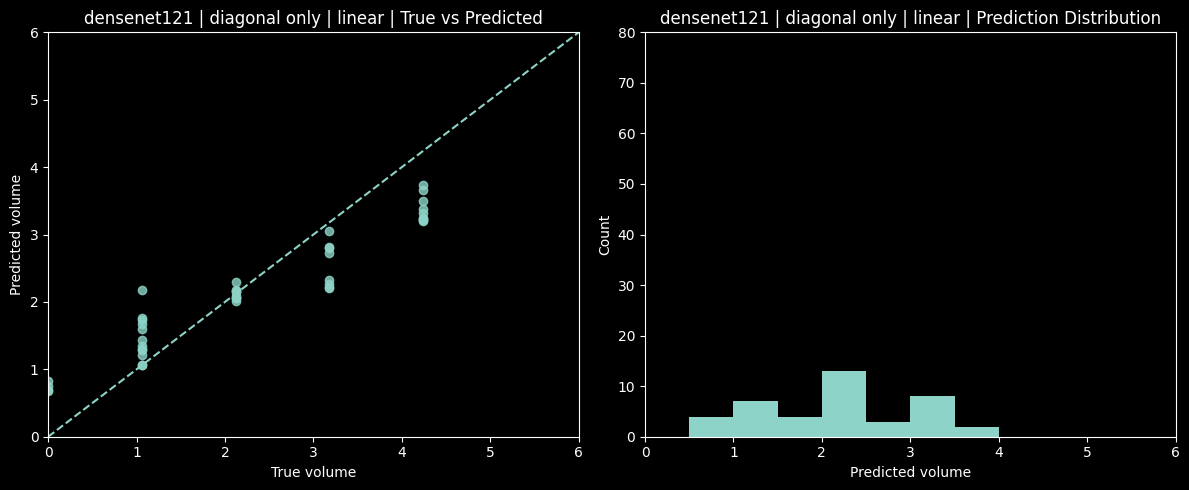

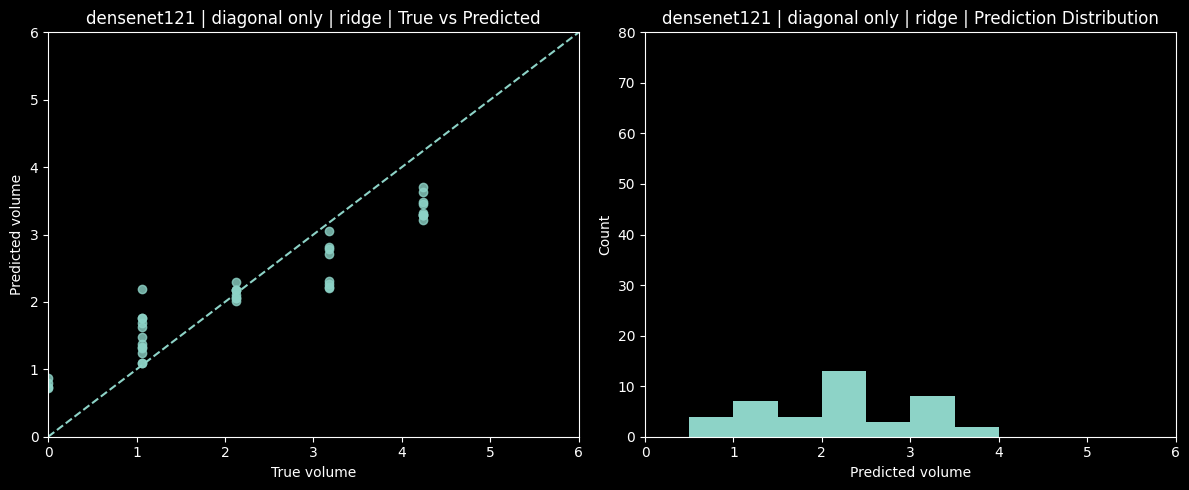

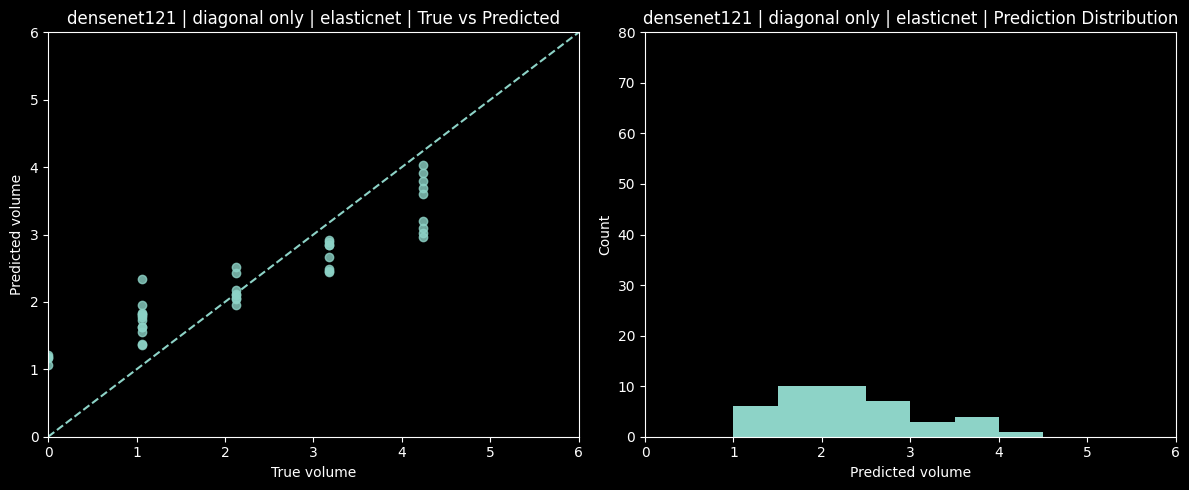

In [8]:
display(results_df)

for _, row in results_df.head(5).iterrows():
    key = (row["backbone"], row["fusion"])
    if key in nested_artifacts:
        artifact = nested_artifacts[key]
        y_true = artifact["y"]
        y_pred = artifact["oof_predictions"][row["regressor"]]
        title = f"{row['backbone']} | {row['fusion']} | {row['regressor']}"
        make_oof_plot(y_true, y_pred, title_prefix=title)


## Save results


In [9]:
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
name = f"only_diagonal_frozen_performance_{timestamp}.csv"
results_df.to_csv(OUTPUT_DIR / name, index=False)
print("Saved:", OUTPUT_DIR / name)

hyperparams_name = f"only_diagonal_frozen_performance_best_hyperparameters_{timestamp}.json"

best_hyperparameters = {}
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    config_key = f"{backbone_name}__{fusion_name}"
    best_hyperparameters[config_key] = {}
    for regressor_name, folds in artifact["nested_results"].items():
        fold_params = [
            {
                "fold": f["fold"],
                "best_params": f["best_params"],
                "MAE": f.get("MAE"),
                "RMSE": f.get("RMSE"),
                "R2": f.get("R2"),
                "MSE": f.get("MSE"),
            }
            for f in folds
        ]

        best_hyperparameters[config_key][regressor_name] = fold_params

with open(OUTPUT_DIR / hyperparams_name, "w") as f:
    json.dump(best_hyperparameters, f, indent=2, default=str)

print("Saved:", OUTPUT_DIR / hyperparams_name)

oof_rows = []
sample_meta = samples[["exp_id", "volume", "pic_path"]].reset_index(drop=True)

for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    for regressor_name, y_pred in artifact["oof_predictions"].items():
        y_true = artifact["y"]
        for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
            oof_rows.append({
                "backbone": backbone_name,
                "fusion": fusion_name,
                "regressor": regressor_name,
                "sample_idx": i,
                "exp_id": sample_meta.loc[i, "exp_id"],
                "pic_path": sample_meta.loc[i, "pic_path"],
                "volume": sample_meta.loc[i, "volume"],
                "y_true": float(yt),
                "y_pred": float(yp),
                "residual": float(yp - yt),
                "abs_error": float(abs(yp - yt)),
            })

oof_df = pd.DataFrame(oof_rows)
oof_name = f"only_diagonal_frozen_performance_oof_predictions_{timestamp}.csv"
oof_df.to_csv(OUTPUT_DIR / oof_name, index=False)

print("Saved:", OUTPUT_DIR / oof_name)

Saved: results/only_diagonal_frozen_performance_2026-04-03_00-21-10.csv
Saved: results/only_diagonal_frozen_performance_best_hyperparameters_2026-04-03_00-21-10.json
Saved: results/only_diagonal_frozen_performance_oof_predictions_2026-04-03_00-21-10.csv
